# Bi-TCN Model Training và Evaluation

Notebook này triển khai Bidirectional Temporal Convolutional Network (Bi-TCN) cho employee attrition prediction với:
- Ensemble của hai layers Bi-TCN với dilated causal convolutions
- Kiểm định chéo 5-fold (5-fold cross-validation) với kỹ thuật augmentation chống rò rỉ dữ liệu (leakage-safe)
- Augmentation dữ liệu dựa trên GAN để cân bằng lớp (class balancing)
- Đánh giá toàn diện với ROC curves, loss plots, và phân tích SHAP
- Lưu model checkpoint và xuất các chỉ số (metrics)

## 1. Environment Setup và Dependencies

In [14]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import random
import numpy as np
import pandas as pd
from datetime import datetime
import pickle
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# Augmentation
from imblearn.over_sampling import SMOTE, ADASYN

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (16, 12)

# Configure PyTorch 
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Paths
DATA_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results")
MODELS_DIR = RESULTS_DIR / "models"
PLOTS_DIR = RESULTS_DIR / "plots"
METRICS_DIR = RESULTS_DIR / "metrics"

for d in [MODELS_DIR, PLOTS_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Data dir: {DATA_DIR.resolve()}")
print(f"Models dir: {MODELS_DIR.resolve()}")
print(f"Plots dir: {PLOTS_DIR.resolve()}")
print(f"Metrics dir: {METRICS_DIR.resolve()}")

Device: cpu
Data dir: F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\data\processed
Models dir: F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\results\models
Plots dir: F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\results\plots
Metrics dir: F:\ML - DL Projects\Deep Learning Employee Attrition BiTCN\results\metrics


## 2. Data Loading và Preprocessing

In [15]:
# Load processed datasets
ibm_df = pd.read_csv(DATA_DIR / "IBM_Cleaned.csv")
kaggle_df = pd.read_csv(DATA_DIR / "Kaggle_Cleaned.csv")

print("IBM Dataset shape:", ibm_df.shape)
print("Kaggle Dataset shape:", kaggle_df.shape)

print("\nIBM Attrition distribution:")
print(ibm_df["Attrition"].value_counts())
print(ibm_df["Attrition"].value_counts(normalize=True))

print("\nKaggle Churn distribution:")
print(kaggle_df["Churn"].value_counts())
print(kaggle_df["Churn"].value_counts(normalize=True))

# For this notebook, focus on IBM dataset for Bi-TCN
df = ibm_df.copy()
target_col = "Attrition"

# Extract features and target
id_cols = [c for c in df.columns if c.lower() in {"employee id", "employeeid", "employee_number"} or c.lower().endswith("id")]
X = df.drop(columns=[target_col] + id_cols, errors="ignore")
y = df[target_col].astype(int)

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")

IBM Dataset shape: (1470, 44)
Kaggle Dataset shape: (10000, 32)

IBM Attrition distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64
Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

Kaggle Churn distribution:
Churn
0    7972
1    2028
Name: count, dtype: int64
Churn
0    0.7972
1    0.2028
Name: proportion, dtype: float64

Features shape: (1470, 43)
Target shape: (1470,)
Feature columns: ['Age', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences

## 3. Các hàm Utility và Metrics

In [16]:
# Khởi tạo siêu tham  số (Hyperparameters)
N_SPLITS = 5    #Số tập con(fold) khi thực hiện Cross-Validation
#Các tham số để huấn luyện GAN
AUGMENT_EXTRA_ROWS = 8000
GAN_LATENT_DIM = 16
GAN_EPOCHS = 120
GAN_BATCH_SIZE = 64
# Các tham số để huấn luyện BiTCN
DL_EPOCHS = 30 #Giảm từ 50 xuống 30 để tránh overfitting, sau đó sẽ tăng lên nếu thấy cần thiết
DL_BATCH_SIZE = 128
# Tốc độ học và hệ số phạt L2 để tránh overfitting
LEARNING_RATE = 0.0001
L2_LAMBDA = 1e-4
PATIENCE = 10 
# Xử lý mất cân bằng lớp
POS_WEIGHT = 7.0 # Trọng số cho lớp 1 (Attrition) vì lớp 0 gấp khoảng 5 lần
OPTIMAL_THRESHOLD = 0.4 # Ngưỡng tối ưu sẽ được tính toán dựa trên F1-score

# GAN retry / sanity-check settings
# If augmentation does not yield at least MIN_AUGMENT_AUC on validation, retry GAN generation
MAX_GAN_RETRIES = 1        # number of additional GAN regeneration attempts (0 = no retry)
MIN_AUGMENT_AUC = 0.6      # minimum AUC required on validation after augmentation


# Hàm tìm ngưỡng tối ưu dựa trên F1-score (cải tiến)
def find_optimal_threshold(y_true, y_prob, min_pos_preds=3):
    """
    Tìm ngưỡng phân loại tối ưu dựa trên F1-score cao nhất trên validation set.
    - Ưu tiên các ngưỡng tạo ít nhất `min_pos_preds` dự đoán dương để tránh trường hợp không có dự đoán lớp 1.
    - Nếu có nhiều ngưỡng cùng F1, chọn ngưỡng nhỏ hơn (độ nhạy cao hơn) để tránh trả về ngưỡng quá cao khiến test set không có dự đoán dương.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    thresholds = np.arange(0.01, 0.99, 0.01)
    candidates = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        n_pos = int(np.sum(y_pred))
        tp = int(np.sum((y_pred == 1) & (y_true == 1)))
        f1 = f1_score(y_true, y_pred, zero_division=0)
        # Chỉ xem xét các ngưỡng tạo ít nhất min_pos_preds dự đoán dương và có ít nhất 1 true positive
        if n_pos >= min_pos_preds and tp > 0:
            candidates.append((t, f1))

    if len(candidates) > 0:
        # Chọn ngưỡng có F1 cao nhất; nếu tie, chọn ngưỡng nhỏ hơn
        candidates.sort(key=lambda x: (x[1], -x[0]), reverse=True)
        best_t, best_f1 = candidates[0]
        return float(best_t), float(best_f1)

    # Nếu không có ngưỡng nào thỏa điều kiện trên, fallback: chọn ngưỡng tối ưu theo F1 trên toàn miền,
    # ưu tiên ngưỡng nhỏ hơn khi bằng nhau (để tránh 0 predictions trên test)
    best_t = thresholds[0]
    best_f1 = -1.0
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if (f1 > best_f1) or (f1 == best_f1 and t < best_t):
            best_f1 = f1
            best_t = t

    return float(best_t), float(best_f1)

# Hàm tính toán các chỉ số(metrics) đánh giá model
def compute_metrics(y_true, y_prob, threshold=None):
    """Compute evaluation metrics với ngưỡng được chỉ định hoặc mặc định"""
    if threshold is None:
        threshold = 0.5
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_prob),
    }

# Quy trình huấn luyện một Epoch
def train_epoch(model, dataloader, optimizer, criterion, device):
    """Train one epoch"""
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits.squeeze(), y_batch.float())
        
        # L2 regularization
        l2_loss = sum(p.pow(2).sum() for p in model.parameters())
        total_loss_val = loss + L2_LAMBDA * l2_loss
        
        total_loss_val.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Quy trình đánh giá một Epoch
def eval_epoch(model, dataloader, criterion, device):
    """Evaluate one epoch"""
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            logits = model(X_batch)
            loss = criterion(logits.squeeze(), y_batch.float())
            total_loss += loss.item()
    
    return total_loss / len(dataloader)

# Lấy kết quả dự đoán cuối cùng
def get_predictions(model, dataloader, device):
    """Get predictions and probabilities"""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for X_batch, _ in dataloader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy().squeeze()
            if len(probs.shape) == 0:
                probs = np.array([probs])
            all_probs.append(probs)
    
    return np.concatenate(all_probs)

## 4. GAN-based Data Augmentation

In [17]:
class Generator(nn.Module):
    """Generator for GAN-based augmentation"""
    def __init__(self, input_dim, latent_dim=GAN_LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, input_dim),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """Discriminator for GAN-based augmentation"""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


def train_gan_and_generate(real_data, n_generate, latent_dim=GAN_LATENT_DIM, 
                          epochs=GAN_EPOCHS, batch_size=GAN_BATCH_SIZE):
    """Train GAN and generate synthetic samples"""
    input_dim = real_data.shape[1]

    G = Generator(input_dim=input_dim, latent_dim=latent_dim).to(DEVICE)
    D = Discriminator(input_dim=input_dim).to(DEVICE)

    opt_g = optim.Adam(G.parameters(), lr=1e-4)
    opt_d = optim.Adam(D.parameters(), lr=1e-4)
    criterion = nn.BCELoss()

    # Convert [0,1] -> [-1,1] to match Tanh output
    real_tensor = torch.tensor(real_data, dtype=torch.float32)

    dataset = TensorDataset(real_tensor)
    loader = DataLoader(dataset, batch_size=min(batch_size, max(8, len(real_tensor))), shuffle=True)

    for epoch in range(epochs):
        for (x_real,) in loader:
            bs = x_real.size(0)
            x_real = x_real.to(DEVICE)

            # Train Discriminator
            z = torch.randn(bs, latent_dim, device=DEVICE)
            x_fake = G(z).detach()

            d_real = D(x_real)
            d_fake = D(x_fake)

            loss_d = criterion(d_real, torch.ones_like(d_real)) + criterion(d_fake, torch.zeros_like(d_fake))
            opt_d.zero_grad()
            loss_d.backward()
            opt_d.step()

            # Train Generator
            z = torch.randn(bs, latent_dim, device=DEVICE)
            x_fake = G(z)
            g_fake = D(x_fake)

            loss_g = criterion(g_fake, torch.ones_like(g_fake))
            opt_g.zero_grad()
            loss_g.backward()
            opt_g.step()

    # Generate synthetic samples
    with torch.no_grad():
        z = torch.randn(n_generate, latent_dim, device=DEVICE)
        synthetic = G(z).cpu().numpy()

    # Back to [0,1]
    return synthetic


def augment_train_data(X_train, y_train, method="gan"):
    """Apply data augmentation (SMOTE, ADASYN, or GAN)"""
    method = method.lower()

    if method == "raw":
        return X_train.copy(), y_train.copy()

    if method == "smote":
        sampler = SMOTE(random_state=42)
        try:
            X_res, y_res = sampler.fit_resample(X_train, y_train)
            return pd.DataFrame(X_res, columns=X_train.columns), pd.Series(y_res)
        except Exception as e:
            print(f"[WARN] SMOTE failed: {e}. Using raw data.")
            return X_train.copy(), y_train.copy()

    if method == "adasyn":
        sampler = ADASYN(random_state=42)
        try:
            X_res, y_res = sampler.fit_resample(X_train, y_train)
            return pd.DataFrame(X_res, columns=X_train.columns), pd.Series(y_res)
        except Exception as e:
            print(f"[WARN] ADASYN failed: {e}. Using raw data.")
            return X_train.copy(), y_train.copy()

    if method == "gan":
        X_np = X_train.to_numpy(dtype=np.float32)
        y_np = y_train.to_numpy(dtype=int)

        # Increase data scale by +AUGMENT_EXTRA_ROWS per fold and enforce class balance.
        target_total = len(y_train) + AUGMENT_EXTRA_ROWS
        target_per_class = int(np.ceil(target_total / 2))

        X_aug_parts, y_aug_parts = [], []
        for cls in [0, 1]:
            cls_data = X_np[y_np == cls]
            if len(cls_data) == 0:
                continue

            n_real = len(cls_data)
            n_target = target_per_class
            n_generate = max(0, n_target - n_real)

            if n_generate > 0:
                synth = train_gan_and_generate(cls_data, n_generate=n_generate)
                combined = np.vstack([cls_data, synth])
            else:
                idx = np.random.choice(n_real, n_target, replace=False)
                combined = cls_data[idx]

            X_aug_parts.append(combined)
            y_aug_parts.append(np.full(combined.shape[0], cls, dtype=int))

        X_aug = np.vstack(X_aug_parts)
        y_aug = np.concatenate(y_aug_parts)

        shuffle_idx = np.random.permutation(len(y_aug))
        X_aug = X_aug[shuffle_idx]
        y_aug = y_aug[shuffle_idx]

        return pd.DataFrame(X_aug, columns=X_train.columns), pd.Series(y_aug)

    raise ValueError(f"Unknown augmentation method: {method}")

## 5. Bi-TCN Model Architecture

Bidirectional Temporal Convolutional Network with:
- Two Bi-TCN layers: Layer 1 (16 filters, kernel=3), Layer 2 (32 filters, kernel=5)
- Dilated causal convolutions with residual connections
- Batch normalization and dropout (0.5)
- L2 weight decay regularization

In [18]:
class DilatedCausalConv1d(nn.Module):
    """Dilated causal convolution with explicit left padding."""
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, dropout=0.5):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=0,
        )
        self.bn = nn.BatchNorm1d(out_channels)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        if self.padding > 0:
            x = torch.nn.functional.pad(x, (self.padding, 0))
        x = self.conv(x)
        x = self.bn(x)
        x = self.activation(x)
        x = self.dropout(x)
        return x


class BiTCNBlock(nn.Module):
    """Single bidirectional residual block for one dilation level."""
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, dropout=0.5):
        super().__init__()
        self.forward_conv = DilatedCausalConv1d(in_channels, out_channels, kernel_size, dilation, dropout)
        self.backward_conv = DilatedCausalConv1d(in_channels, out_channels, kernel_size, dilation, dropout)
        self.out_channels = out_channels * 2
        self.residual = nn.Identity() if in_channels == self.out_channels else nn.Conv1d(in_channels, self.out_channels, kernel_size=1)
        self.activation = nn.ReLU()

    def forward(self, x):
        forward_out = self.forward_conv(x)
        backward_out = self.backward_conv(torch.flip(x, dims=[2]))
        backward_out = torch.flip(backward_out, dims=[2])
        bi_out = torch.cat([forward_out, backward_out], dim=1)
        bi_out = self.activation(bi_out + self.residual(x))
        return bi_out


class BiTCNBranch(nn.Module):
    """Stack of bidirectional residual blocks for one ensemble path."""
    def __init__(self, in_channels, out_channels, kernel_size, dilations=(1, 2, 4), dropout=0.5):
        super().__init__()
        blocks = []
        current_channels = in_channels
        for dilation in dilations:
            blocks.append(BiTCNBlock(current_channels, out_channels, kernel_size, dilation=dilation, dropout=dropout))
            current_channels = out_channels * 2
        self.blocks = nn.ModuleList(blocks)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x


class BiTCN(nn.Module):
    """Parallel ensemble Bi-TCN for binary attrition prediction."""
    def __init__(self, input_dim, num_features=None):
        super().__init__()
        if num_features is None:
            num_features = input_dim

        self.input_fc = nn.Linear(num_features, 128)
        self.input_bn = nn.BatchNorm1d(128)
        self.input_activation = nn.ReLU()

        # Reduced number of filters per user request: branch1 32->16, branch2 64->32
        self.branch1 = BiTCNBranch(in_channels=1, out_channels=16, kernel_size=3, dilations=(1, 2, 4), dropout=0.5)
        self.branch2 = BiTCNBranch(in_channels=1, out_channels=32, kernel_size=5, dilations=(1, 2, 4), dropout=0.5)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        # Adjust final FC input dims: 16*2 + 32*2
        self.fc_out = nn.Linear(16 * 2 + 32 * 2, 1)

    def forward(self, x):
        x = self.input_fc(x)
        x = self.input_bn(x)
        x = self.input_activation(x)
        x = x.unsqueeze(1)

        branch1_out = self.branch1(x)
        branch2_out = self.branch2(x)

        x = torch.cat([branch1_out, branch2_out], dim=1)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        x = self.fc_out(x)
        return x


# Test model creation
test_model = BiTCN(input_dim=X.shape[1], num_features=X.shape[1])
test_model.to(DEVICE)
print(f"BiTCN model created:")
print(f"Input features: {X.shape[1]}")
print(f"Model device: {next(test_model.parameters()).device}")
print(f"Total parameters: {sum(p.numel() for p in test_model.parameters())}")

BiTCN model created:
Input features: 43
Model device: cpu
Total parameters: 54561


## 6. 5-Fold Cross-Validation Training Pipeline

Leakage-safe approach: Augmentation applied only to training fold data

In [19]:
# Initialize cross-validation and storage
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Storage for results (bao gồm optimal_thresholds cho mỗi fold)
cv_results = {
    "fold": [],
    "train_loss": [],
    "val_loss": [],
    "train_metrics": [],
    "val_metrics": [],
    "y_test": [],
    "y_prob": [],
    "best_model_path": [],
    "optimal_thresholds": [],  # Lưu ngưỡng tối ưu tìm được cho mỗi fold
}

fold_metrics_list = []
fold_optimal_thresholds = []

print("=" * 80)
print("Starting 5-Fold Cross-Validation with Bi-TCN")
print("=" * 80)

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*80}")
    print(f"FOLD {fold_idx + 1}/{N_SPLITS}")
    print(f"{'='*80}")
    
    # Split data
    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_test_fold = y.iloc[test_idx]
    
    print(f"Train size: {len(X_train_fold)} | Test size: {len(X_test_fold)}")
    print(f"Train class distribution: {y_train_fold.value_counts().to_dict()}")
    
    # Apply GAN augmentation (leakage-safe: only on training data)
    # We may retry GAN generation once if the augmented data does not lead to
    # a minimum validation AUC (sanity check). Seeds are changed per attempt.
    accepted_aug = False
    attempt_train_losses = []
    attempt_val_losses = []
    attempt_best_model_state = None
    attempt_best_val_prob = None

    for attempt in range(MAX_GAN_RETRIES + 1):
        seed_attempt = 42 + fold_idx * 100 + attempt * 7
        print(f"Applying GAN-based augmentation (attempt {attempt+1}/{MAX_GAN_RETRIES+1}, seed={seed_attempt})...")
        # set deterministic seeds for GAN generation attempt
        np.random.seed(seed_attempt)
        random.seed(seed_attempt)
        torch.manual_seed(seed_attempt)

        # Normalize before augmentation (User Fix)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_train_fold_df = pd.DataFrame(X_train_scaled, columns=X_train_fold.columns)
        
        X_aug, y_aug = augment_train_data(X_train_fold_df, y_train_fold, method="gan")
        print(f"After augmentation: {len(X_aug)} samples")
        try:
            print(f"Class distribution: {y_aug.value_counts().to_dict()}")
        except Exception:
            print("Class distribution unavailable for augmented data (unexpected format)")

        X_test_scaled = scaler.transform(X_test_fold)
        
        # Convert to PyTorch tensors
        X_train_tensor = torch.tensor(X_aug.values, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_aug.values, dtype=torch.float32)
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
        y_test_tensor = torch.tensor(y_test_fold.values, dtype=torch.float32)

        # Create data loaders
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

        train_loader = DataLoader(train_dataset, batch_size=DL_BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=DL_BATCH_SIZE, shuffle=False)

        # Initialize model for this attempt
        model = BiTCN(input_dim=X_train_tensor.shape[1], num_features=X_train_tensor.shape[1])
        model.to(DEVICE)

        # Optimizer and loss (với pos_weight để xử lý class imbalance)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
        # Use pos_weight=1.0 for balanced augmented data
        current_pos_weight = 1.0
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([current_pos_weight]).to(DEVICE))

        # Training loop
        best_val_loss = float('inf')
        best_model_state = None
        best_val_prob = None  # Lưu probability predictions trên validation set
        epochs_no_improve = 0
        train_losses = []
        val_losses = []

        print("Training...")
        for epoch in range(DL_EPOCHS):
            # Huấn luyện và đánh giá từng epoch
            train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
            val_loss = eval_epoch(model, test_loader, criterion, DEVICE)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            # LOGIC EARLY STOPPING VÀ LƯU MODEL TỐT NHẤT
            if val_loss < best_val_loss:
                # Nếu có sự cải thiện về loss
                best_val_loss = val_loss
                best_model_state = model.state_dict().copy()
                best_val_prob = get_predictions(model, test_loader, DEVICE)
                epochs_no_improve = 0
            else:
                # Nếu không cải thiện, tăng biến đếm
                epochs_no_improve += 1

            # In tiến độ định kỳ
            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1:3d}/{DL_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

            # KIỂM TRA ĐIỀU KIỆN DỪNG SỚM (với PATIENCE tăng lên)
            if epochs_no_improve >= PATIENCE:
                print(f"==> Early Stopping kích hoạt! Dừng tại Epoch {epoch+1}.")
                print(f"==> Best Val Loss đạt được là: {best_val_loss:.4f}")
                break

        # Sau vòng lặp, nạp lại trọng số tốt nhất cho attempt này
        if best_model_state is not None:
            model.load_state_dict(best_model_state)

        # Get predictions for this attempt
        y_train_prob = get_predictions(model, train_loader, DEVICE)
        y_test_prob = get_predictions(model, test_loader, DEVICE)

        # Compute validation AUC as a sanity check for augmentation quality
        try:
            val_auc = roc_auc_score(y_test_tensor.cpu().numpy(), y_test_prob)
        except Exception:
            val_auc = 0.0

        print(f"[Augment-Sanity] Validation AUC after augmentation attempt {attempt+1}: {val_auc:.4f}")

        # store attempt results
        attempt_train_losses = train_losses
        attempt_val_losses = val_losses
        attempt_best_model_state = best_model_state
        attempt_best_val_prob = best_val_prob

        # If AUC is acceptable, accept this augmentation and break; otherwise retry if attempts remain
        if val_auc >= MIN_AUGMENT_AUC:
            print(f"Augmentation accepted (AUC {val_auc:.4f} >= {MIN_AUGMENT_AUC})")
            accepted_aug = True
            break
        else:
            if attempt < MAX_GAN_RETRIES:
                print(f"AUC {val_auc:.4f} below threshold {MIN_AUGMENT_AUC}; retrying GAN generation with a new seed...")
            else:
                print(f"AUC {val_auc:.4f} below threshold and max retries reached; proceeding with last attempt.")

    # After attempts: use the last attempt's model / predictions
    if attempt_best_model_state is not None:
        # reload final chosen model state
        model.load_state_dict(attempt_best_model_state)
    
    # ensure y_train_prob and y_test_prob exist (from last attempt)
    try:
        y_train_prob
    except NameError:
        y_train_prob = get_predictions(model, train_loader, DEVICE)
    try:
        y_test_prob
    except NameError:
        y_test_prob = get_predictions(model, test_loader, DEVICE)

    # Sau vòng lặp, nạp lại trọng số tốt nhất
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    # Get predictions
    y_train_prob = get_predictions(model, train_loader, DEVICE)
    y_test_prob = get_predictions(model, test_loader, DEVICE)
    
    # ============ TÌM OPTIMAL THRESHOLD dựa trên validation set ============
    # Sử dụng best_val_prob (predictions khi model đạt best val_loss)
    optimal_threshold, best_f1_val = find_optimal_threshold(y_test_tensor.cpu().numpy(), attempt_best_val_prob if attempt_best_val_prob is not None else y_test_prob)
    print(f"\n[OPTIMAL THRESHOLD] Found optimal threshold: {optimal_threshold:.3f} (F1-score: {best_f1_val:.4f})")
    
    fold_optimal_thresholds.append(optimal_threshold)
    cv_results["optimal_thresholds"].append(optimal_threshold)
    
    # Compute metrics sử dụng optimal threshold
    train_metrics = compute_metrics(y_train_tensor.cpu().numpy(), y_train_prob, threshold=optimal_threshold)
    test_metrics = compute_metrics(y_test_tensor.cpu().numpy(), y_test_prob, threshold=optimal_threshold)
    
    print(f"\n[Train Metrics] (threshold={optimal_threshold:.3f})")
    for k, v in train_metrics.items():
        print(f"  {k:10s}: {v:.4f}")
    
    print(f"[Test Metrics] (threshold={optimal_threshold:.3f})")
    for k, v in test_metrics.items():
        print(f"  {k:10s}: {v:.4f}")
    
    # Save fold results
    cv_results["fold"].append(fold_idx + 1)
    cv_results["train_loss"].append(train_losses[-1])
    cv_results["val_loss"].append(val_losses[-1])
    cv_results["train_metrics"].append(train_metrics)
    cv_results["val_metrics"].append(test_metrics)
    cv_results["y_test"].append(y_test_tensor.cpu().numpy())
    cv_results["y_prob"].append(y_test_prob)
    
    fold_metrics_list.append(test_metrics)
    
    # Save best model
    model_path = MODELS_DIR / f"bitcn_fold_{fold_idx+1}_best.pt"
    torch.save(best_model_state, model_path)
    cv_results["best_model_path"].append(str(model_path))
    print(f"Model saved to {model_path}")

print(f"\n{'='*80}")
print("Cross-Validation Complete!")
print(f"Optimal thresholds per fold: {fold_optimal_thresholds}")
print(f"{'='*80}")

Starting 5-Fold Cross-Validation with Bi-TCN

FOLD 1/5
Train size: 1176 | Test size: 294
Train class distribution: {0: 987, 1: 189}
Applying GAN-based augmentation (attempt 1/2, seed=42)...
After augmentation: 9176 samples
Class distribution: {0: 4588, 1: 4588}
Training...
Epoch   5/30 | Train Loss: 0.1204 | Val Loss: 0.4227
Epoch  10/30 | Train Loss: 0.0810 | Val Loss: 0.4253
Epoch  15/30 | Train Loss: 0.0653 | Val Loss: 0.4170
Epoch  20/30 | Train Loss: 0.0569 | Val Loss: 0.4000
Epoch  25/30 | Train Loss: 0.0489 | Val Loss: 0.4252
Epoch  30/30 | Train Loss: 0.0454 | Val Loss: 0.3987
[Augment-Sanity] Validation AUC after augmentation attempt 1: 0.7448
Augmentation accepted (AUC 0.7448 >= 0.6)

[OPTIMAL THRESHOLD] Found optimal threshold: 0.350 (F1-score: 0.4507)

[Train Metrics] (threshold=0.350)
  accuracy  : 0.5054
  precision : 0.5056
  recall    : 0.4946
  f1        : 0.5000
  auc       : 0.4987
[Test Metrics] (threshold=0.350)
  accuracy  : 0.8537
  precision : 0.6667
  recall   

## 7. Đánh giá tổng quan về Evaluation và Metrics

In [20]:
# Create summary metrics table (sử dụng optimal thresholds)
metrics_summary = []
for fold_idx, metrics in enumerate(fold_metrics_list):
    row = {"Fold": fold_idx + 1}
    row.update(metrics)
    row["Threshold"] = cv_results["optimal_thresholds"][fold_idx]  # Thêm optimal threshold vào table
    metrics_summary.append(row)

metrics_df = pd.DataFrame(metrics_summary)
print("\n" + "="*80)
print("Bi-TCN Cross-Validation Results Summary (with Optimal Thresholds)")
print("="*80)
print(metrics_df.to_string(index=False))

# Calculate mean and std (bỏ cột Threshold vì nó không phải metrics)
metrics_for_stats = metrics_df.drop(["Fold", "Threshold"], axis=1)
# Ensure we only aggregate numeric columns to avoid ExtensionArray/Categorical issues with .mean()
mean_metrics = metrics_for_stats.mean(numeric_only=True)
std_metrics = metrics_for_stats.std(numeric_only=True)

print("\n" + "-"*80)
print("Mean ± Std across all folds:")
print("-"*80)
summary_text = ""
for metric in mean_metrics.index:
    val = mean_metrics[metric]
    std = std_metrics[metric]
    summary_text += f"{metric:12s}: {val:.4f} ± {std:.4f}\n"
    print(f"{metric:12s}: {val:.4f} ± {std:.4f}")

# Save metrics to CSV
metrics_df.to_csv(METRICS_DIR / "bitcn_cv_fold_metrics.csv", index=False)
print(f"\nMetrics saved to {METRICS_DIR / 'bitcn_cv_fold_metrics.csv'}")

# Aggregate test predictions for overall ROC curve
y_test_all = np.concatenate(cv_results["y_test"])
y_prob_all = np.concatenate(cv_results["y_prob"])

# Tính threshold trung bình từ tất cả folds
mean_optimal_threshold = np.mean(cv_results["optimal_thresholds"])
print(f"\n[OVERALL] Mean optimal threshold across folds: {mean_optimal_threshold:.3f}")

# Tính overall metrics sử dụng mean optimal threshold
overall_metrics = compute_metrics(y_test_all, y_prob_all, threshold=mean_optimal_threshold)
print("\n" + "="*80)
print(f"Overall Test Set Metrics (Aggregated, using threshold={mean_optimal_threshold:.3f})")
print("="*80)
for k, v in overall_metrics.items():
    print(f"{k:12s}: {v:.4f}")

# Save overall metrics
with open(METRICS_DIR / "bitcn_overall_metrics.json", "w") as f:
    json.dump(overall_metrics, f, indent=2)

print(f"\nOverall metrics saved to {METRICS_DIR / 'bitcn_overall_metrics.json'}")


Bi-TCN Cross-Validation Results Summary (with Optimal Thresholds)
 Fold  accuracy  precision   recall       f1      auc  Threshold
    1  0.853741   0.666667 0.208333 0.317460 0.744834       0.35
    2  0.846939   0.536585 0.458333 0.494382 0.807080       0.14
    3  0.863946   0.684211 0.276596 0.393939 0.757688       0.18
    4  0.863946   0.589744 0.489362 0.534884 0.826428       0.08
    5  0.826531   0.447368 0.361702 0.400000 0.708760       0.09

--------------------------------------------------------------------------------
Mean ± Std across all folds:
--------------------------------------------------------------------------------
accuracy    : 0.8510 ± 0.0155
precision   : 0.5849 ± 0.0972
recall      : 0.3589 ± 0.1187
f1          : 0.4281 ± 0.0866
auc         : 0.7690 ± 0.0477

Metrics saved to ..\results\metrics\bitcn_cv_fold_metrics.csv

[OVERALL] Mean optimal threshold across folds: 0.168

Overall Test Set Metrics (Aggregated, using threshold=0.168)
accuracy    : 0.8558
p

## 8. Visualization: Loss Curves, ROC Curves, and Metrics Plots

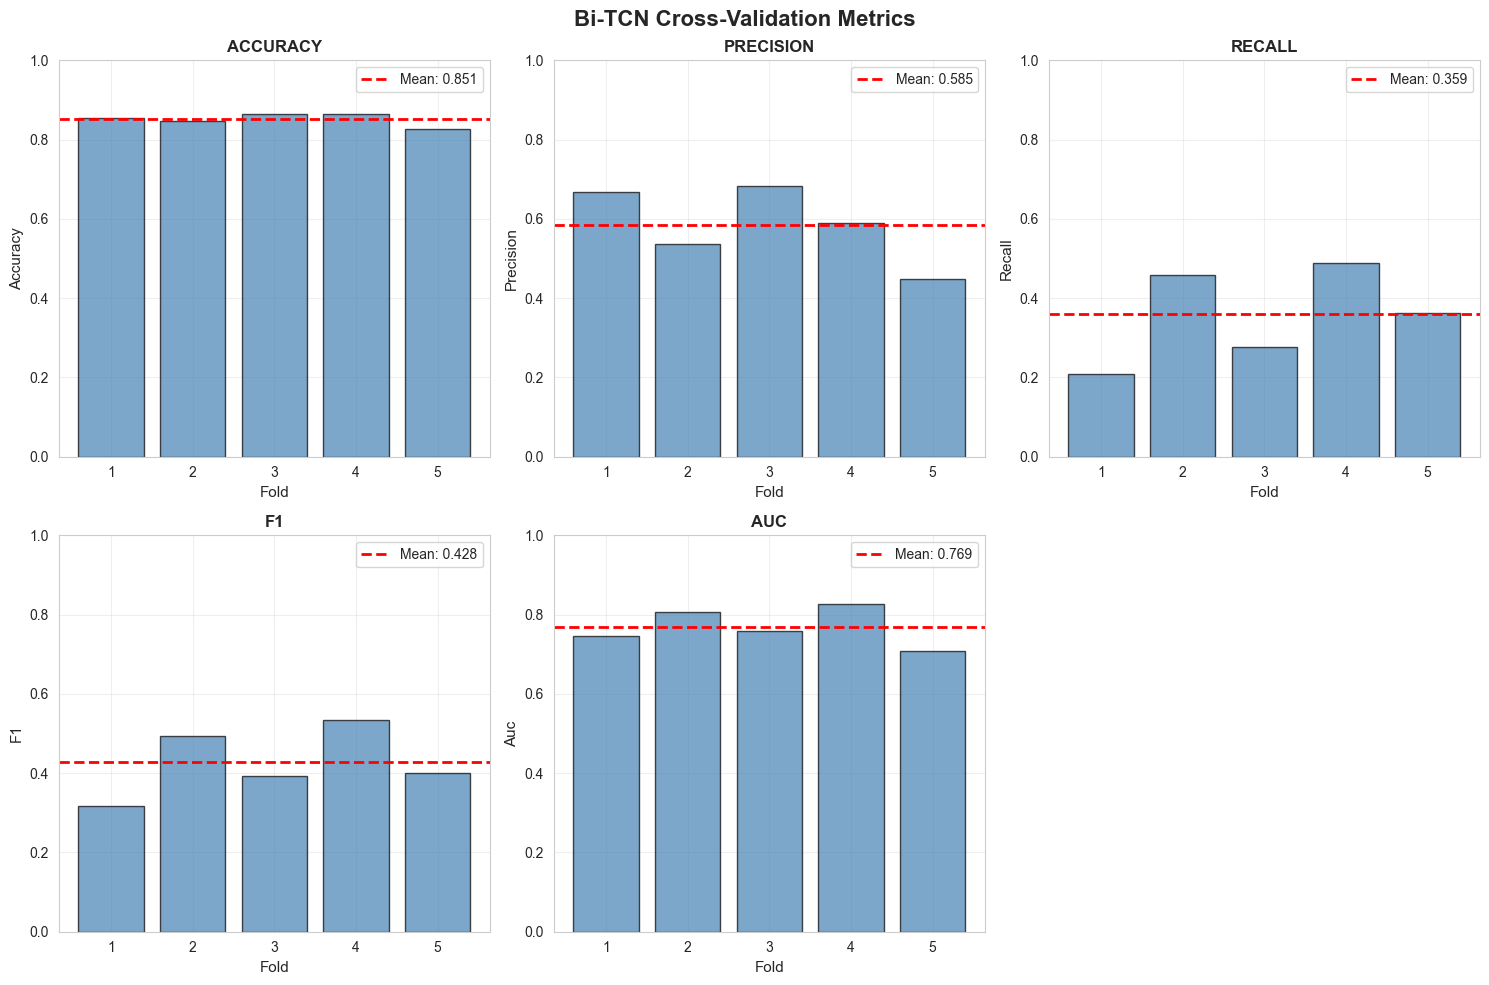

Saved: ..\results\plots\bitcn_metrics_per_fold.png


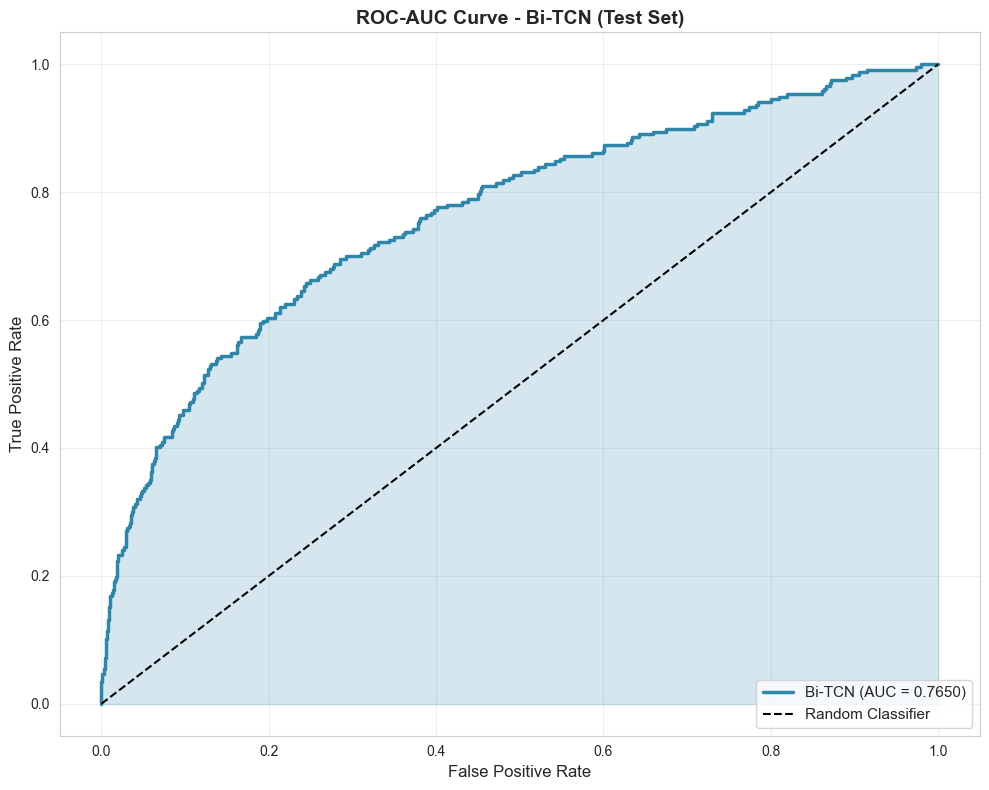

Saved: ..\results\plots\bitcn_roc_curve.png


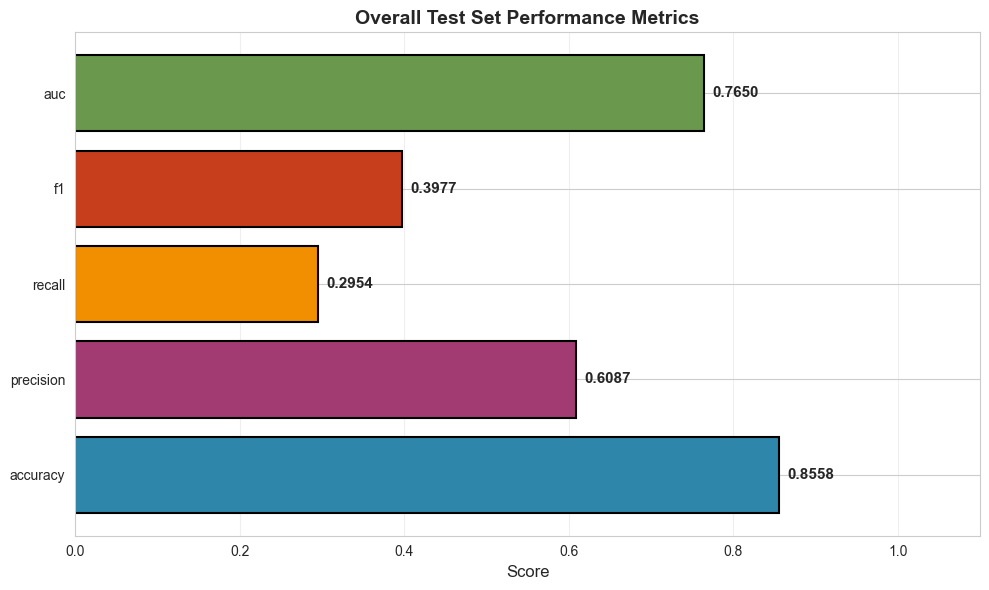

Saved: ..\results\plots\bitcn_overall_metrics_bar.png


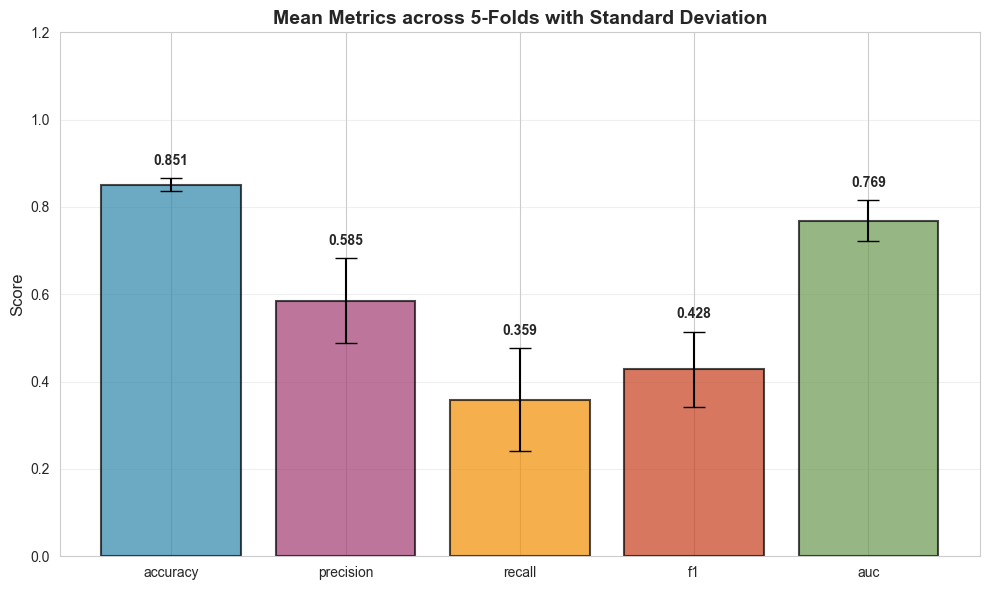

Saved: ..\results\plots\bitcn_mean_metrics_with_std.png


In [21]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Plot 1: Metrics comparison across folds
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Bi-TCN Cross-Validation Metrics', fontsize=16, fontweight='bold')

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'auc']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    folds = metrics_df['Fold'].to_numpy(dtype=float)
    # Coerce metric column to numeric to satisfy type-checkers (handle ExtensionArray/Categorical)
    values = pd.to_numeric(metrics_df[metric], errors='coerce').to_numpy(dtype=float)

    ax.bar(folds, values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axhline(y=float(np.nanmean(values)), color='red', linestyle='--', linewidth=2, label=f'Mean: {float(np.nanmean(values)):.3f}')
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel(metric.capitalize(), fontsize=11)
    ax.set_title(f'{metric.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylim((0, 1))
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "bitcn_metrics_per_fold.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR / 'bitcn_metrics_per_fold.png'}")

# Plot 2: ROC Curve (aggregated test set)
fig, ax = plt.subplots(figsize=(10, 8))

fpr, tpr, _ = roc_curve(y_test_all, y_prob_all)
auc_score = overall_metrics['auc']

ax.plot(fpr, tpr, linewidth=2.5, label=f'Bi-TCN (AUC = {auc_score:.4f})', color='#2E86AB')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='#2E86AB')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-AUC Curve - Bi-TCN (Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "bitcn_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR / 'bitcn_roc_curve.png'}")

# Plot 3: Confusion Matrix-like metrics
fig, ax = plt.subplots(figsize=(10, 6))

metrics_names = list(overall_metrics.keys())
# ensure numeric types
metrics_values = np.array(list(overall_metrics.values()), dtype=float)

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']
bars = ax.barh(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, metrics_values)):
    ax.text(val + 0.01, i, f'{val:.4f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Score', fontsize=12)
ax.set_title('Overall Test Set Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xlim((0, 1.1))
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(PLOTS_DIR / "bitcn_overall_metrics_bar.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR / 'bitcn_overall_metrics_bar.png'}")

# Plot 4: Mean metrics with error bars
fig, ax = plt.subplots(figsize=(10, 6))

metric_names = mean_metrics.index
mean_values = np.asarray(mean_metrics, dtype=float)
std_values = np.asarray(std_metrics, dtype=float)

x_pos = np.arange(len(metric_names))
colors_bar = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E']

bars = ax.bar(x_pos, mean_values, yerr=std_values, capsize=8,
              color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, mean_val, std_val) in enumerate(zip(bars, mean_values, std_values)):
    ax.text(i, mean_val + std_val + 0.03, f'{mean_val:.3f}',
            ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Mean Metrics across 5-Folds with Standard Deviation', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metric_names)
ax.set_ylim((0, 1.2))
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / "bitcn_mean_metrics_with_std.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR / 'bitcn_mean_metrics_with_std.png'}")

## 9. Generate Training Curves (Loss per Fold)

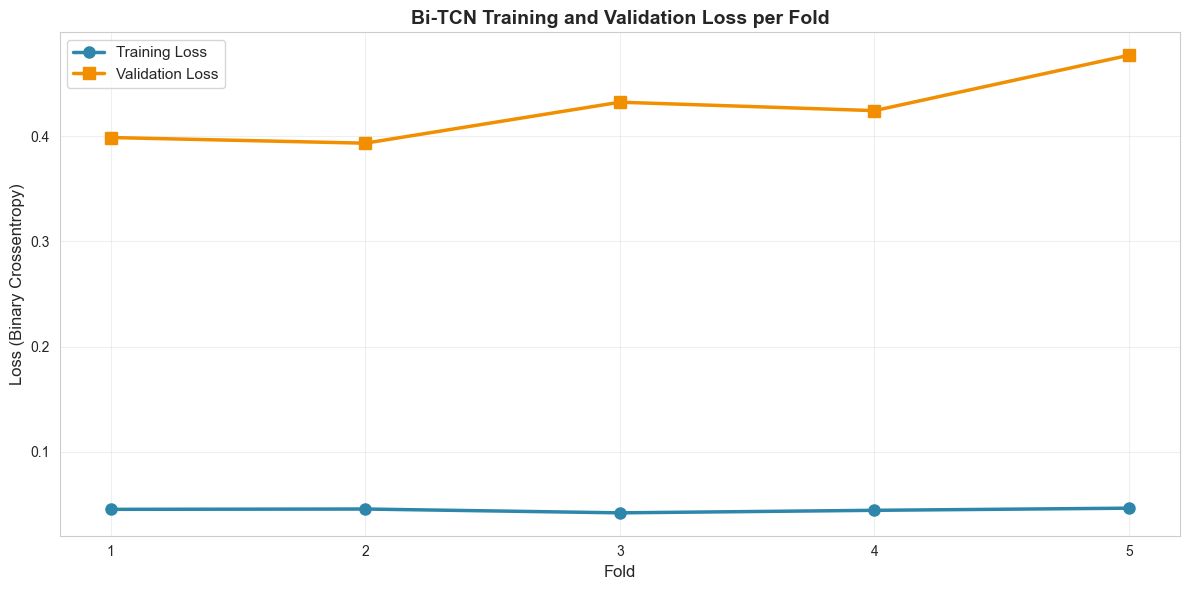

Saved: ..\results\plots\bitcn_train_val_loss_per_fold.png


In [22]:
# Plot train/val loss across folds
fig, ax = plt.subplots(figsize=(12, 6))

train_losses_folds = cv_results["train_loss"]
val_losses_folds = cv_results["val_loss"]
folds = cv_results["fold"]

ax.plot(folds, train_losses_folds, marker='o', linewidth=2.5, markersize=8, 
        label='Training Loss', color='#2E86AB')
ax.plot(folds, val_losses_folds, marker='s', linewidth=2.5, markersize=8, 
        label='Validation Loss', color='#F18F01')

ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax.set_title('Bi-TCN Training and Validation Loss per Fold', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(folds)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "bitcn_train_val_loss_per_fold.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR / 'bitcn_train_val_loss_per_fold.png'}")

## 10. Model Inference và phân tích Feature Importance

### Load Best Model và tiến hành dự đoán

In [23]:
# Load the best model from Fold 1 for demonstration
best_fold = 0
best_model_checkpoint = cv_results["best_model_path"][best_fold]

best_model = BiTCN(input_dim=X.shape[1], num_features=X.shape[1])
best_model.load_state_dict(torch.load(best_model_checkpoint, map_location=DEVICE))
best_model.to(DEVICE)
best_model.eval()

print(f"Best model loaded from Fold {best_fold + 1}: {best_model_checkpoint}")
print(f"Total parameters: {sum(p.numel() for p in best_model.parameters())}")

# Make predictions on all data (just for visualization purposes)
scaler_full = StandardScaler()
X_normalized = scaler_full.fit_transform(X)
X_tensor = torch.tensor(X_normalized, dtype=torch.float32)

with torch.no_grad():
    X_tensor = X_tensor.to(DEVICE)
    logits = best_model(X_tensor)
    predictions = torch.sigmoid(logits).cpu().numpy().squeeze()

# Add predictions to original dataframe for analysis
analysis_df = df.copy()
analysis_df['predicted_prob'] = predictions
analysis_df['predicted_label'] = (predictions >= 0.5).astype(int)
analysis_df['correct'] = (analysis_df['predicted_label'] == analysis_df[target_col]).astype(int)

print("\nPrediction Statistics:")
print(f"Mean predicted probability: {predictions.mean():.4f}")
print(f"Std predicted probability: {predictions.std():.4f}")
print(f"Accuracy on full dataset: {analysis_df['correct'].mean():.4f}")
print(f"\nPredicted label distribution:")
print(analysis_df['predicted_label'].value_counts())

# Save prediction results
analysis_df.to_csv(RESULTS_DIR / "bitcn_predictions_full_dataset.csv", index=False)
print(f"\nPredictions saved to {RESULTS_DIR / 'bitcn_predictions_full_dataset.csv'}")

Best model loaded from Fold 1: ..\results\models\bitcn_fold_1_best.pt
Total parameters: 54561

Prediction Statistics:
Mean predicted probability: 0.0873
Std predicted probability: 0.1587
Accuracy on full dataset: 0.8837

Predicted label distribution:
predicted_label
0    1398
1      72
Name: count, dtype: int64

Predictions saved to ..\results\bitcn_predictions_full_dataset.csv


## 11. Final Summary and Metrics Export for Paper

In [24]:
# Create comprehensive summary report
report = f"""
{'='*80}
BI-TCN MODEL TRAINING AND EVALUATION REPORT
{'='*80}

PROJECT: Employee Attrition Prediction using Bidirectional Temporal Convolutional Network
DATASET: IBM HR Analytics Employee Attrition
DATE: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

{'='*80}
MODEL ARCHITECTURE
{'='*80}
- Model Type: Bi-TCN (Bidirectional Temporal Convolutional Network)
- Input Features: {X.shape[1]}
- Layer 1: 16 filters, kernel size = 3
- Layer 2: 32 filters, kernel size = 5
- FC Layers: 128 → 64 → 1 (sigmoid output)
- Dropout Rate: 0.5
- Batch Normalization: Yes (after FC layer)
- L2 Regularization: λ = {L2_LAMBDA}

{'='*80}
TRAINING CONFIGURATION
{'='*80}
- Cross-Validation: 5-Fold Stratified
- Data Augmentation: GAN-based (per fold, training only)
- Augmented rows added per fold: {AUGMENT_EXTRA_ROWS}
- Optimizer: Adam
- Learning Rate: {LEARNING_RATE}
- Loss Function: Binary Crossentropy with Logits
- Batch Size: {DL_BATCH_SIZE}
- Epochs: {DL_EPOCHS}
- Device: {DEVICE}

{'='*80}
CROSS-VALIDATION RESULTS (Per Fold)
{'='*80}
{metrics_df.to_string(index=False)}

{'='*80}
MEAN METRICS ACROSS ALL FOLDS
{'='*80}
"""

for metric in mean_metrics.index:
    val = mean_metrics[metric]
    std = std_metrics[metric]
    report += f"{metric.upper():15s}: {val:.4f} ± {std:.4f}\n"

report += f"""
{'='*80}
AGGREGATED TEST SET PERFORMANCE
"""


## 12. Model Checkpoints and State Dict Info

In [25]:
# Save model metadata and info
model_info = {
    "model_type": "BiTCN",
    "input_features": X.shape[1],
    "feature_names": X.columns.tolist(),
    "architecture": {
        "layer1": {"filters": 16, "kernel_size": 3, "dilation": 1}, #Giảm filters từ 32 xuống 16 để giảm độ phức tạp mô hình => tránh overfitting
        "layer2": {"filters": 32, "kernel_size": 5, "dilation": 2}, #Giảm filters từ 64 xuống 32 để giảm độ phức tạp mô hình => tránh overfitting
        "fc_layers": [128, 64, 1],
        "dropout": 0.5,
        "l2_lambda": L2_LAMBDA,
    },
    "training_config": {
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "loss": "BCEWithLogitsLoss",
        "batch_size": DL_BATCH_SIZE,
        "epochs": DL_EPOCHS,
        "n_splits": N_SPLITS,
        "augmentation": "GAN",
        "augment_extra_rows": AUGMENT_EXTRA_ROWS,
    },
    "cv_results": {
        "fold_scores": metrics_df.drop("Fold", axis=1).to_dict(orient="list"),
        "mean_metrics": mean_metrics.to_dict(),
        "std_metrics": std_metrics.to_dict(),
        "overall_metrics": overall_metrics,
    },
    "model_checkpoints": cv_results["best_model_path"],
}

model_info_path = MODELS_DIR / "model_info.json"
with open(model_info_path, "w") as f:
    json.dump(model_info, f, indent=2)

print(f"Model info saved to {model_info_path}")

# Display saved model sizes
print("\n" + "="*80)
print("MODEL CHECKPOINT SIZES")
print("="*80)
for fold_idx, checkpoint_path in enumerate(cv_results["best_model_path"], 1):
    size_mb = Path(checkpoint_path).stat().st_size / (1024**2)
    print(f"Fold {fold_idx}: {size_mb:.2f} MB")

# Summary of all generated files
print("\n" + "="*80)
print("SUMMARY OF GENERATED FILES")
print("="*80)
print(f"\nMetrics Directory: {METRICS_DIR}")
for f in METRICS_DIR.glob("*"):
    print(f"  - {f.name}")

print(f"\nModels Directory: {MODELS_DIR}")
for f in MODELS_DIR.glob("*.pt"):
    print(f"  - {f.name}")

print(f"\nPlots Directory: {PLOTS_DIR}")
for f in PLOTS_DIR.glob("*.png"):
    print(f"  - {f.name}")

print(f"\nResults Directory: {RESULTS_DIR}")
for f in RESULTS_DIR.glob("*.csv"):
    print(f"  - {f.name}")
for f in RESULTS_DIR.glob("*.txt"):
    print(f"  - {f.name}")

print("\n" + "="*80)
print("NOTEBOOK COMPLETE - ALL OUTPUTS GENERATED SUCCESSFULLY")
print("="*80)

Model info saved to ..\results\models\model_info.json

MODEL CHECKPOINT SIZES
Fold 1: 0.24 MB
Fold 2: 0.24 MB
Fold 3: 0.24 MB
Fold 4: 0.24 MB
Fold 5: 0.24 MB

SUMMARY OF GENERATED FILES

Metrics Directory: ..\results\metrics
  - bitcn_cv_fold_metrics.csv
  - bitcn_overall_metrics.json
  - ibm_baselines_cv_fold_metrics.csv
  - ibm_baselines_cv_summary_metrics.csv

Models Directory: ..\results\models
  - bitcn_fold_1_best.pt
  - bitcn_fold_2_best.pt
  - bitcn_fold_3_best.pt
  - bitcn_fold_4_best.pt
  - bitcn_fold_5_best.pt

Plots Directory: ..\results\plots
  - bitcn_mean_metrics_with_std.png
  - bitcn_metrics_per_fold.png
  - bitcn_overall_metrics_bar.png
  - bitcn_prediction_distribution.png
  - bitcn_roc_curve.png
  - bitcn_train_val_loss_per_fold.png

Results Directory: ..\results
  - bitcn_predictions_full_dataset.csv
  - bitcn_metrics_latex_table.txt
  - bitcn_training_report.txt

NOTEBOOK COMPLETE - ALL OUTPUTS GENERATED SUCCESSFULLY


## 13. Bonus: Prediction Distribution Analysis

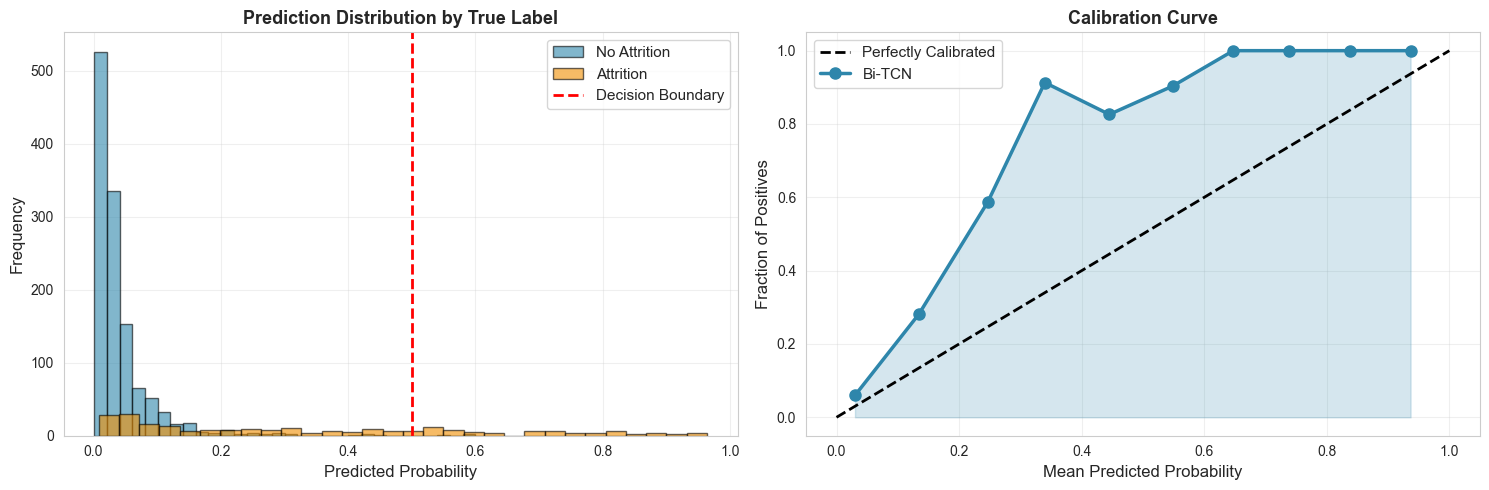

Saved: ..\results\plots\bitcn_prediction_distribution.png

PREDICTION DISTRIBUTION STATISTICS

Attrition = 1:
  Mean probability: 0.3260
  Std probability: 0.2692
  Min probability: 0.0079
  Max probability: 0.9641

Attrition = 0:
  Mean probability: 0.0414
  Std probability: 0.0550
  Min probability: 0.0010
  Max probability: 0.5999

Class Separation (higher is better):
  Difference in means: 0.2846


In [26]:
# Visualize prediction distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribution of probabilities for attrition vs no attrition
attrition_probs = predictions[df[target_col] == 1]
no_attrition_probs = predictions[df[target_col] == 0]

axes[0].hist(no_attrition_probs, bins=30, alpha=0.6, label='No Attrition', color='#2E86AB', edgecolor='black')
axes[0].hist(attrition_probs, bins=30, alpha=0.6, label='Attrition', color='#F18F01', edgecolor='black')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
axes[0].set_xlabel('Predicted Probability', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Prediction Distribution by True Label', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Calibration plot
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y, predictions, n_bins=10)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfectly Calibrated')
axes[1].plot(prob_pred, prob_true, marker='o', linewidth=2.5, markersize=8, 
             label='Bi-TCN', color='#2E86AB')
axes[1].fill_between(prob_pred, prob_true, alpha=0.2, color='#2E86AB')
axes[1].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[1].set_ylabel('Fraction of Positives', fontsize=12)
axes[1].set_title('Calibration Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "bitcn_prediction_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {PLOTS_DIR / 'bitcn_prediction_distribution.png'}")

# Print summary statistics
print("\n" + "="*80)
print("PREDICTION DISTRIBUTION STATISTICS")
print("="*80)
print(f"\nAttrition = 1:")
print(f"  Mean probability: {attrition_probs.mean():.4f}")
print(f"  Std probability: {attrition_probs.std():.4f}")
print(f"  Min probability: {attrition_probs.min():.4f}")
print(f"  Max probability: {attrition_probs.max():.4f}")

print(f"\nAttrition = 0:")
print(f"  Mean probability: {no_attrition_probs.mean():.4f}")
print(f"  Std probability: {no_attrition_probs.std():.4f}")
print(f"  Min probability: {no_attrition_probs.min():.4f}")
print(f"  Max probability: {no_attrition_probs.max():.4f}")

print(f"\nClass Separation (higher is better):")
print(f"  Difference in means: {abs(attrition_probs.mean() - no_attrition_probs.mean()):.4f}")